# Step 1 : Create the Project:

AI_Data_Analyst_Agent/
│
├── data/
│   └── employee_data.csv
│
├── notebooks/
│   └── AI_Data_Analyst.ipynb
│
├── outputs/
│
└── .env

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # Importing all the necessary libaries.

print("AI Data Analyst Project Started") # A specific heading to be printed on the top.

AI Data Analyst Project Started


In [6]:
# Import the datatset or the csv file on which the analysis will be performed. (Load the dataset)

df=pd.read_csv(r"C:\Users\Shouvik\Downloads\13924525-employees.csv")
df

,Employee_ID,Name,Age,Department,City,Experience,Salary,Performance
0,101,Aarav,28,Sales,Hyderabad,10,93191.0,76.0
1,102,Vivaan,26,HR,Delhi,6,66426.0,68.0
2,103,Aditya,29,Marketing,Bangalore,7,76822.0,85.0
3,104,Arjun,26,HR,Bangalore,5,57933.0,70.0
4,105,Kabir,26,IT,Bangalore,9,93809.0,76.0
5,106,Rohan,33,IT,Pune,10,97274.0,87.0
6,107,Rahul,31,Sales,Bangalore,2,37899.0,88.0
7,108,Amit,25,IT,NaN,4,52890.0,88.0
8,109,Karan,26,IT,Mumbai,3,51292.0,70.0
9,110,Rohit,35,HR,Mumbai,8,82513.0,82.0


In [7]:
df.head() # To view the data

,Employee_ID,Name,Age,Department,City,Experience,Salary,Performance
0,101,Aarav,28,Sales,Hyderabad,10,93191.0,76.0
1,102,Vivaan,26,HR,Delhi,6,66426.0,68.0
2,103,Aditya,29,Marketing,Bangalore,7,76822.0,85.0
3,104,Arjun,26,HR,Bangalore,5,57933.0,70.0
4,105,Kabir,26,IT,Bangalore,9,93809.0,76.0


In [8]:
# To understand the dataset:

print("Shape :",df.shape)
print("\nColumns :", df.columns.tolist())
print("\nData Types :")
print(df.dtypes)

Shape : (50, 8)

Columns : ['Employee_ID', 'Name', 'Age', 'Department', 'City', 'Experience', 'Salary', 'Performance']

Data Types :
Employee_ID      int64
Name            object
Age              int64
Department      object
City            object
Experience       int64
Salary         float64
Performance    float64
dtype: object


In [9]:
# To check for missing values in the dataset.
print(df.isnull().sum())

Employee_ID    0
Name           0
Age            0
Department     1
City           1
Experience     0
Salary         1
Performance    1
dtype: int64


In [10]:
# To check for duplicate rows :
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [11]:
# Now data cleaning :

df = df.drop_duplicates()

print("Updated shape:",df.shape)

Updated shape: (50, 8)


In [12]:
# Now cleansing the data :

# Filling up the missing categorical values.
df["Department"] = df["Department"].fillna("Unknown")
df["City"] = df["City"].fillna("Unknown") 

# Filling up the salary and performance column missing values by using median function. 
df["Salary"] = df["Salary"].fillna(df["Salary"].median())
df["Performance"] = df["Performance"].fillna(df["Performance"].median())

In [13]:
df # Checking the data.

,Employee_ID,Name,Age,Department,City,Experience,Salary,Performance
0,101,Aarav,28,Sales,Hyderabad,10,93191.0,76.0
1,102,Vivaan,26,HR,Delhi,6,66426.0,68.0
2,103,Aditya,29,Marketing,Bangalore,7,76822.0,85.0
3,104,Arjun,26,HR,Bangalore,5,57933.0,70.0
4,105,Kabir,26,IT,Bangalore,9,93809.0,76.0
5,106,Rohan,33,IT,Pune,10,97274.0,87.0
6,107,Rahul,31,Sales,Bangalore,2,37899.0,88.0
7,108,Amit,25,IT,Unknown,4,52890.0,88.0
8,109,Karan,26,IT,Mumbai,3,51292.0,70.0
9,110,Rohit,35,HR,Mumbai,8,82513.0,82.0


In [14]:
df.isnull().sum() # Now no missing values in the data.

Employee_ID    0
Name           0
Age            0
Department     0
City           0
Experience     0
Salary         0
Performance    0
dtype: int64

In [15]:
# Now since the data cleaning is done, now we will perform some basic analysis over the data and make 
# python understand about how the data is behaving.

print("Total number of employees:", len(df))

print("Average Age:", df["Age"].mean())

print("Average Experience:", df["Experience"].mean())

print("Average Salary:", df["Salary"].mean())

print("Highest Salary:", df["Salary"].max())

print("Lowest Salary:", df["Salary"].min())

print("Average Performance:", df["Performance"].mean())

print("\nEmployees by Department:")
print(df["Department"].value_counts())

print("\nEmployees by City:")
print(df["City"].value_counts())

print("\nAverage Salary by Department:")
print(df.groupby("Department")["Salary"].mean())


Total number of employees: 50
Average Age: 28.18
Average Experience: 5.56
Average Salary: 66475.88
Highest Salary: 102243.0
Lowest Salary: 24636.0
Average Performance: 79.52

Employees by Department:
Department
IT           14
Sales        11
Marketing     9
Finance       8
HR            7
Unknown       1
Name: count, dtype: int64

Employees by City:
City
Bangalore    14
Pune         12
Delhi        11
Hyderabad     5
Mumbai        4
Chennai       3
Unknown       1
Name: count, dtype: int64

Average Salary by Department:
Department
Finance      69273.125000
HR           58081.714286
IT           69029.857143
Marketing    68615.777778
Sales        68125.454545
Unknown      29697.000000
Name: Salary, dtype: float64


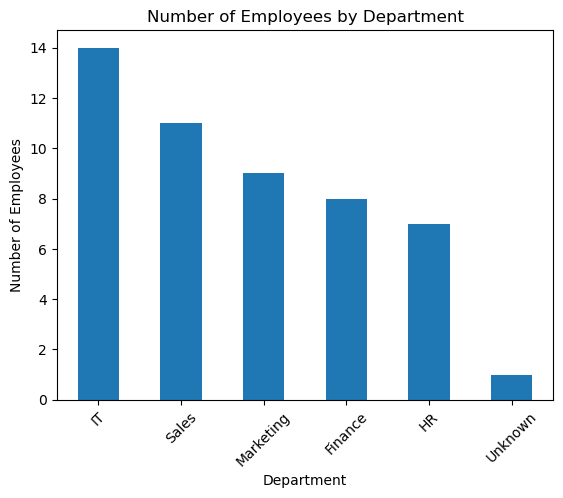

In [16]:
# Data Visualization and Exploratory Data Analysis.

df["Department"].value_counts().plot(kind="bar")

plt.title("Number of Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()

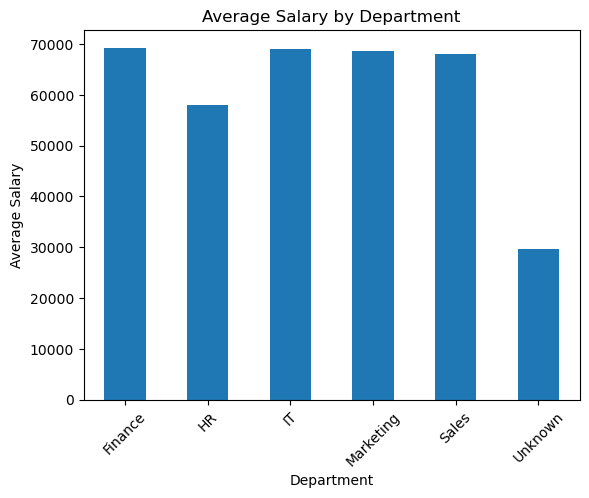

In [17]:
df.groupby("Department")["Salary"].mean().plot(kind="bar")

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.show()

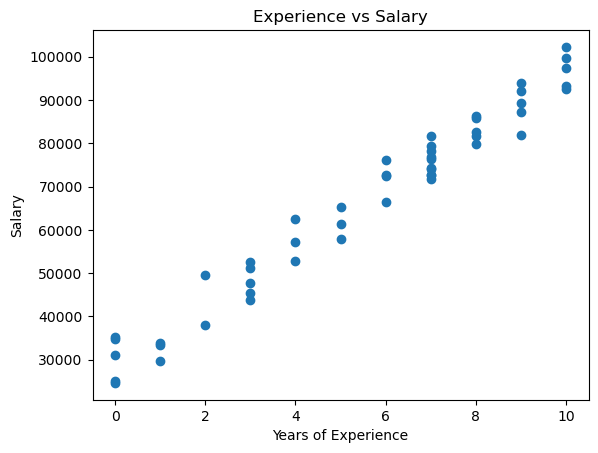

In [18]:
plt.scatter(df["Experience"], df["Salary"])

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [19]:
# Building Reusable Analysis Functions, which can be used by the AI Agent for analysis:

# Function 1 : Total Employees:

def total_employees():
    return len(df)

# Test Function 1:
total_employees()

50

In [20]:
# Function 2 : Average Salary:

def average_salary():
    return df["Salary"].mean()

# Test Function 2:
average_salary()

np.float64(66475.88)

In [21]:
# Function 3 : Highest Salary:

def highest_salary():
    return df["Salary"].max()

# Test Function 3:

highest_salary()

102243.0

In [22]:
# Function 4 : Average Experience:

def average_experience():
    return df["Experience"].mean()

# Test Function 4:

average_experience()

np.float64(5.56)

In [23]:
# Function 5 : Average Performance:

def average_performance():
    return df["Performance"].mean()

# Test Function 5:

average_performance()

np.float64(79.52)

In [24]:
# Function 6 : Employees by Department:

def employees_by_department():
    return df["Department"].value_counts()

# Test Function 6:

employees_by_department()

Department
IT           14
Sales        11
Marketing     9
Finance       8
HR            7
Unknown       1
Name: count, dtype: int64

In [25]:
# Function 7 : Employees by City:

def employees_by_city():
    return df["City"].value_counts()

# Test Function 7:

employees_by_city()

City
Bangalore    14
Pune         12
Delhi        11
Hyderabad     5
Mumbai        4
Chennai       3
Unknown       1
Name: count, dtype: int64

In [26]:
# Function 8 : Average Salary by Department:

def salary_by_department():
    return df.groupby("Department")["Salary"].mean().sort_values(ascending=False)

# Test Function 8:

salary_by_department()

Department
Finance      69273.125000
IT           69029.857143
Marketing    68615.777778
Sales        68125.454545
HR           58081.714286
Unknown      29697.000000
Name: Salary, dtype: float64

In [27]:
# Function 9 : Experience vs Salary:

def experience_salary_analysis():
    return df["Experience"].corr(df["Salary"])

# Test Function 9:

experience_salary_analysis()

np.float64(0.9842466596074244)

In [28]:
# Function 10 : Average Performance by Department:

def performance_by_department():
    return df.groupby("Department")["Performance"].mean().sort_values(ascending=False)

# Test Function 10:

performance_by_department()

Department
Unknown      85.000000
IT           80.928571
Finance      80.750000
Marketing    79.888889
HR           79.714286
Sales        75.909091
Name: Performance, dtype: float64

In [ ]:
# Now we will introduce an AI Agent (LLM) to understand on how to work on the business queries from over the 
# 10 functions we have created above. These functions will act as a tool for the AI Agent.

                  USER
                   │
                   │
                   ▼
            "Which department
             pays the most?"
                   │
                   ▼
                 LLM
          Understands the question
                   │
                   ▼
          Selects appropriate tool
                   │
                   ▼
       salary_by_department()
                   │
                   ▼
             Employee Data
                   │
                   ▼
              Analysis
                   │
                   ▼
                 LLM
          Explains the result
                   │
                   ▼
              USER ANSWER

In [48]:
!pip install openai

In [50]:
from openai import OpenAI

In [1]:
import os

print(os.getenv("OPENAI_API_KEY") is not None)

True


In [4]:
!pip install --upgrade openai

  Using cached openai-3.24.0-py3-none-any.whl.metadata (44 kB)
  Using cached httpx2-2.13.1-py3-none-any.whl.metadata (9.8 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 471.5 kB/s eta 0:00:04
   --------- ------------------------------ 0.5/2.1 MB 471.5 kB/s eta 0:00:04
   -------------- ------------------------- 0.8/2.1 MB 526.1 kB/s eta 0:00:03
   -------------- ------------------------- 0.8/2.1 MB 526.1 kB/s eta 0:00:03
   ------------------- -------------------- 1.0/2.1 MB 618.7 kB/s eta 0:00:02
   ------------------------ --------------- 1.3/2.1 MB 674.7 kB/s eta

In [1]:
from openai import OpenAI

print("OpenAI library imported successfully!")

OpenAI library imported successfully!


In [2]:
client = OpenAI()

print("OpenAI client connected successfully!")

OpenAI client connected successfully!


In [6]:
!pip install --upgrade brotli

In [1]:
import brotli

print("Brotli version:", brotli.__version__)

Brotli version: 1.2.0


In [2]:
from openai import OpenAI

client = OpenAI()

print("OpenAI client connected successfully!")

OpenAI client connected successfully!


In [3]:
# Test prompt run:
response = client.responses.create(
    model="gpt-5",
    input="What is an AI Data Analyst Agent? Explain in one simple sentence."
)

print(response.output_text)

An AI Data Analyst Agent is a virtual assistant that uses artificial intelligence to analyze data, answer questions, and automatically generate insights, reports, and visualizations.


In [30]:
# Now we have to give access to the analysis functions that we have created previously for the AI Agent.
tools = {
    "total_employees": total_employees,
    "average_salary": average_salary,
    "highest_salary": highest_salary,
    "average_experience": average_experience,
    "average_performance": average_performance,
    "employees_by_department": employees_by_department,
    "employees_by_city": employees_by_city,
    "salary_by_department": salary_by_department,
    "experience_salary_analysis": experience_salary_analysis,
    "performance_by_department": performance_by_department
}

print("AI Analyst tools created successfully!")

AI Analyst tools created successfully!


In [31]:
# Describing the function tools to the AI:

tool_descriptions = {
    "total_employees": "Returns the total number of employees.",
    
    "average_salary": "Returns the average salary of all employees.",
    
    "highest_salary": "Returns the highest salary among all employees.",
    
    "average_experience": "Returns the average years of experience of employees.",
    
    "average_performance": "Returns the average performance score of employees.",
    
    "employees_by_department": "Returns the number of employees in each department.",
    
    "employees_by_city": "Returns the number of employees in each city.",
    
    "salary_by_department": "Returns the average salary for each department, sorted from highest to lowest.",
    
    "experience_salary_analysis": "Returns the correlation between employee experience and salary.",
    
    "performance_by_department": "Returns the average performance score for each department."
}

print("Tool descriptions created successfully!")

Tool descriptions created successfully!


In [42]:
# Making the AI Agent to understand the user question:

def ask_ai(question):
    
    prompt = f"""
You are an AI Data Analyst working ONLY with an employee dataset.

The available analysis tools are:

{tool_descriptions}

User question:
{question}

Your task:
1. Understand the user's question.
2. Decide whether the question can be answered using the employee dataset.
3. If it can be answered, select the single most appropriate tool.
4. If it cannot be answered using the employee dataset, return exactly:
NO_TOOL

Return ONLY one of the following:
- One tool name from the available tools
- NO_TOOL

Do not provide an explanation.
"""

    response = client.responses.create(
        model="gpt-5",
        input=prompt
    )

    return response.output_text.strip()

In [43]:
# Test Question (Run):
question = "What is the average salary of all employees?"

selected_tool = ask_ai(question)

print("User Question:", question)
print("AI Selected Tool:", selected_tool)

User Question: What is the average salary of all employees?
AI Selected Tool: average_salary


In [52]:
def execute_tool(tool_name):
    
    if tool_name == "NO_TOOL":
        return "This question cannot be answered using the available employee dataset."
    
    if tool_name in tools:
        result = tools[tool_name]()
        return result
    
    else:
        return "Tool not found."

In [54]:
result = execute_tool(selected_tool)

print("Selected Tool:", selected_tool)
print("Analysis Result:", result)

Selected Tool: average_salary
Analysis Result: 66475.88


In [53]:
# Now defining a function which helps the AI to generate an explanation over the analysis being performed.

def generate_insight(question, tool_name, result):
    
    if tool_name == "NO_TOOL":
        return result
    
    prompt = f"""
You are an AI Data Analyst working with an employee dataset.

The user asked:
{question}

The analysis result is:
{result}

Explain the result to the user in simple and clear language.

Do not mention Python, tools, functions, APIs, or technical implementation.
Focus only on answering the user's question.
"""

    response = client.responses.create(
        model="gpt-5",
        input=prompt
    )

    return response.output_text.strip()

In [47]:
insight = generate_insight(
    question,
    selected_tool,
    result
)

print(insight)

The average salary across all employees is $66,475.88.

This means that if you add up all employees’ salaries and divide by the number of employees, the result is $66,475.88.


In [48]:
# Complete AI Analyst Agent:

def ai_data_analyst(question):
    
    # Step 1: AI selects the appropriate tool
    selected_tool = ask_ai(question)
    
    # Step 2: Python executes the selected tool
    result = execute_tool(selected_tool)
    
    # Step 3: AI explains the result
    insight = generate_insight(
        question,
        selected_tool,
        result
    )
    
    return insight

In [49]:
question = "Which department has the highest average salary?"

answer = ai_data_analyst(question)

print("Question:", question)
print("\nAI Analyst Answer:")
print(answer)

Question: Which department has the highest average salary?

AI Analyst Answer:
Finance has the highest average salary, at about $69,273.


In [50]:
ai_data_analyst("Which department has the highest average salary?")

'Finance has the highest average salary, at about $69,273. It’s slightly higher than IT (~$69,030), with Marketing and Sales following behind.'

In [51]:
# Testing our AI Agent ability with different questions:

questions = [
    "How many employees are there?",
    "What is the highest salary?",
    "Which city has the most employees?",
    "What is the average experience of employees?",
    "Which department has the best performance?"
]

for q in questions:
    print("Question:", q)
    print("Answer:", ai_data_analyst(q))
    print("-" * 70)

Question: How many employees are there?
Answer: There are 50 employees in total.
----------------------------------------------------------------------
Question: What is the highest salary?
Answer: The highest salary is 102,243.
----------------------------------------------------------------------
Question: Which city has the most employees?
Answer: Bangalore has the most employees, with 14.
----------------------------------------------------------------------
Question: What is the average experience of employees?
Answer: The average employee has 5.56 years of experience, which is roughly 5 years and 7 months.
----------------------------------------------------------------------
Question: Which department has the best performance?
Answer: - Best overall: the “Unknown” category, with an average performance score of 85.00.
- Best among named departments: IT, with an average score of 80.93.

For context, the rest rank as follows:
- Finance: 80.75
- Marketing: 79.89
- HR: 79.71
- Sales: